# 👗 Smart Fashion AI with Neural Networks (Mid Term)

**Total Marks: 100 (Theory: 10 | Practical: 90)**  


---

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.
5. Have fun!

In [2]:
# Enter your course email here
student_email = "mominhasanemon@gmail.com" # Example: "your.name@university.edu"

---

## 📖 Story: StyleAI — Smart Fashion Recognition

You've just joined **StyleAI**, a startup building an AI-powered wardrobe assistant app. The app lets users snap a photo of any clothing item and instantly classifies it. Your job is to build the **image classification model** that powers this feature.

The dataset is **Fashion-MNIST** — 28×28 grayscale images of 10 clothing categories:

| Label | Class Name |
|-------|------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


---

## Question 1: Theory (10 Marks)

### Part A (3 Marks)
Explain the difference between **Sigmoid** and **ReLU** activation functions. Why is ReLU preferred in hidden layers of deep networks? What problem does Sigmoid cause during backpropagation in deep networks?

### Part B (4 Marks)
In the context of **Gradient Descent**:
- What is the difference between **Batch Gradient Descent**, **Stochastic Gradient Descent (SGD)**, and **Mini-batch Gradient Descent**?
- State one advantage and one disadvantage of each.
- Which type would you recommend for training on Fashion-MNIST (60,000 images), and why?

### Part C (3 Marks)
In our Fashion-MNIST problem (10 classes):
1. Why do we use `nn.CrossEntropyLoss` instead of `nn.BCELoss`?
2. Why should we **NOT** put `nn.Softmax` as the last layer when using `nn.CrossEntropyLoss`?
3. What does `loss.backward()` do?

*Double-click here to write your answers*

**Part A Answer:**

Sigmoid and ReLU are activation functions used in neural networks. The Sigmoid function is:

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

It produces an output between 0 and 1. 

And ReLU (Rectified Linear Unit) is:

$$
\text{ReLU}(x)=\max(0,x)
$$

It outputs 0 for negative inputs and the input itself for positive inputs.

ReLU is preferred in hidden layers of deep networks because it is computationally simple and its derivative is 1 for positive inputs, which allows gradients to propagate more effectively. It also helps reduce the vanishing-gradient problem.

Sigmoid can cause the vanishing-gradient problem during backpropagation. When its input is very large or very small, the function becomes saturated and its derivative becomes very small. In a deep network, multiplying these small gradients through many layers can make the gradients extremely small, causing earlier layers to learn very slowly.

**Part B Answer:**

Batch Gradient Descent calculates the gradient using the entire training dataset before making one update.

**Advantage:** The gradient is stable and accurate because it uses all training samples.

**Disadvantage:** It can be slow and requires more memory, especially for large datasets.

Stochastic Gradient Descent (SGD) calculates the gradient using one training sample at a time and updates the parameters after each sample.

**Advantage:** It requires very little memory and makes frequent updates.

**Disadvantage:** The gradient is noisy, so the loss can fluctuate and training may be less stable.

Mini-batch Gradient Descent calculates the gradient using a small batch of training samples before each update.

**Advantage:** It provides a good balance between computational efficiency, memory usage, and gradient stability.

**Disadvantage:** The choice of batch size affects training performance.

For Fashion-MNIST with 60,000 training images, I would recommend Mini-batch Gradient Descent. It is more computationally efficient than using the entire dataset for every update and more stable than using only one image at a time. A batch size such as 32, 64, or 128 is commonly suitable.

**Part C Answer:**

1. We use `nn.CrossEntropyLoss` instead of `nn.BCELoss` because Fashion-MNIST is a **10-class classification problem**, where each image belongs to exactly one class. `nn.CrossEntropyLoss` is designed for multi-class classification and works directly with the model's raw logits and the target class index. `nn.BCELoss` is generally used for binary classification or independent binary outputs.

2. We should not put `nn.Softmax` as the last layer when using `nn.CrossEntropyLoss` because `nn.CrossEntropyLoss` already applies the required log-softmax operation internally. Therefore, the model should output **raw logits** rather than probabilities.

3. `loss.backward()` performs **backpropagation**. PyTorch's Autograd calculates the gradients of the loss with respect to the model parameters and stores them in their `.grad` attributes. The optimizer can then use these gradients to update the weights using `optimizer.step()`.


---

## Question 2: Load & Explore the Data (15 Marks)

### 2.1 Download the Dataset (1 Marks)

We will use `torchvision.datasets.FashionMNIST` to download the dataset. This is similar to how we loaded data from `.npy` files in class, but here PyTorch handles the download for us.

Run the cell below to download the training and test sets:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Download Fashion-MNIST — this downloads the data into a ./data folder
# download=True means it will download if not already present
full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

train_images_all = full_train_dataset.data.numpy()  # shape: (60000, 28, 28)
train_labels_all = full_train_dataset.targets.numpy()  # shape: (60000,)
test_images_all = test_dataset_raw.data.numpy()
test_labels_all = test_dataset_raw.targets.numpy()

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")
print(f"Image shape: {full_train_dataset[0][0].size}")

Training set size: 60000
Test set size: 10000
Image shape: (28, 28)


### 2.2 Visualize Sample Images (5 Marks)

Create a **2×5 subplot figure** (figsize 12×5) showing one sample image from **each of the 10 classes**.
- Display each image in grayscale (`cmap='gray'`)
- Title each subplot with its class name
- Turn off axis ticks

*Hint: loop through classes 0-9, find one sample of each class, and plot it.*

In [7]:
randomIndex = np.random.randint(0, 6000)
randomIndex

286

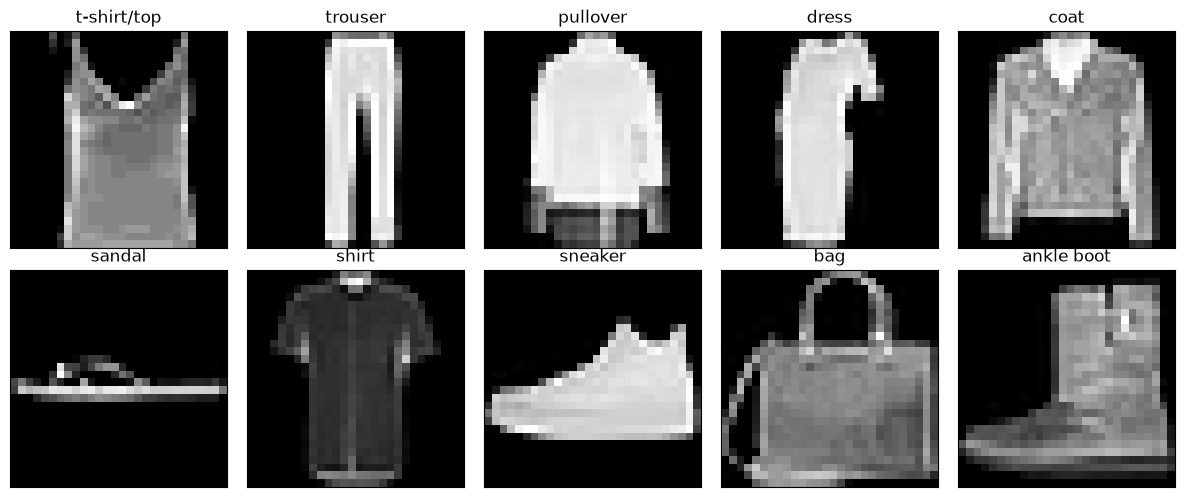

In [8]:
# YOUR CODE HERE

plt.figure(figsize=(12, 5))

for class_idx in range(10):
    # Find the first sample belonging to this class
    sample_idx = np.where(train_labels_all == class_idx)[0][randomIndex]
    
    # Get the corresponding image
    image = train_images_all[sample_idx]

    # Create 2x5 subplot
    plt.subplot(2, 5, class_idx + 1)
    plt.imshow(image, cmap='gray')
    plt.title(class_names[class_idx].lower())
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

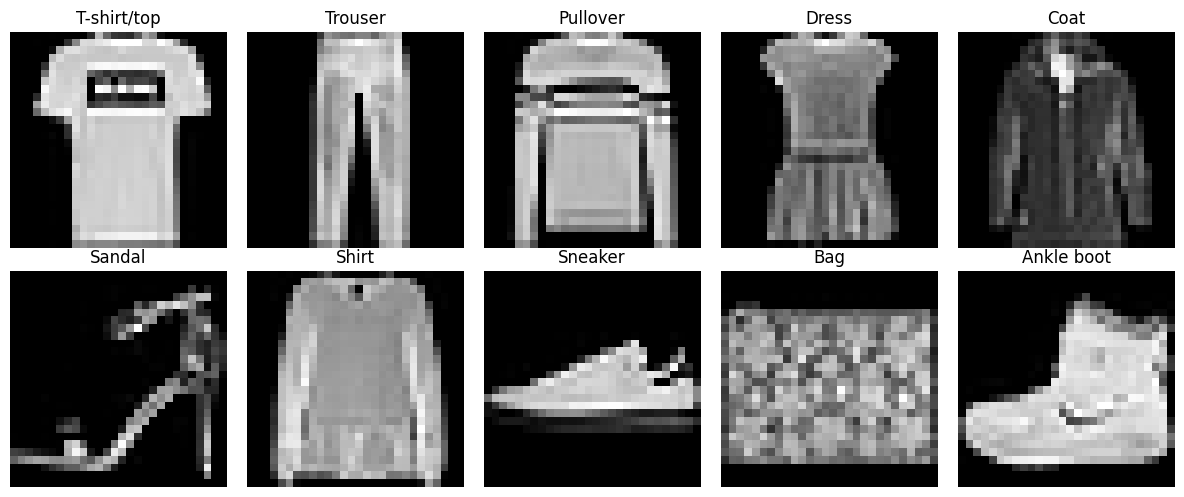

### 2.3 Class Distribution (5 Marks)

Plot a **bar chart** showing how many samples belong to each class in the training set.
- X-axis: class names
- Y-axis: count
- Title: "Training Set Class Distribution"
- Add the count number on top of each bar

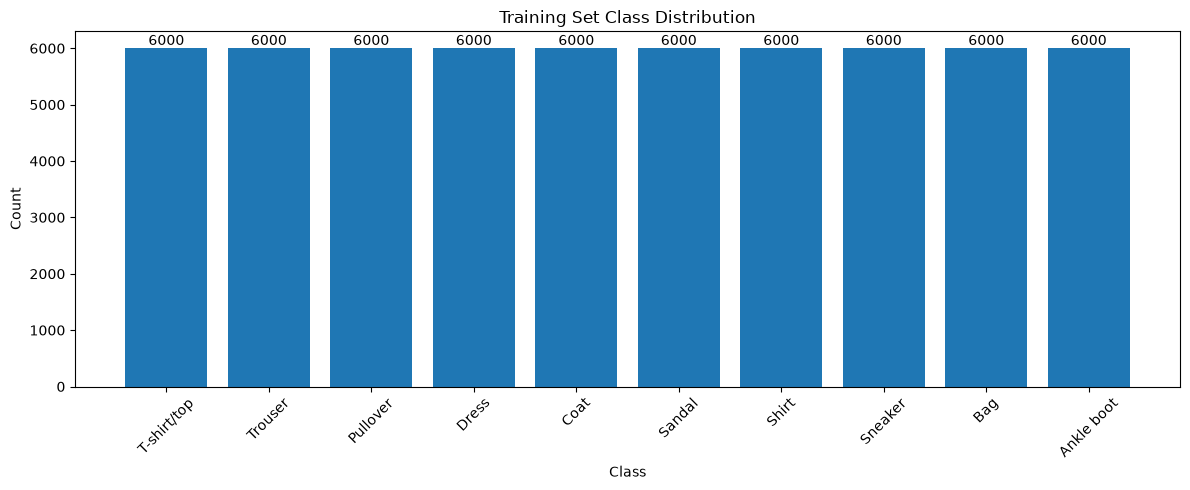

In [9]:
# YOUR CODE HERE


class_counts = np.bincount(train_labels_all, minlength=10)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, class_counts)

for bar, count in zip(bars, class_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha='center',
        va='bottom'
    )

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Training Set Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.4 Prepare Tensors and Split (4 Marks)

Now we need to extract the data as NumPy arrays, normalize it, split it, and convert to PyTorch tensors.



**Your tasks:**
1. Normalize pixel values to **[0, 1]** by dividing by 255.0.
2. Split training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
3. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (tensors), `y_train, y_val, y_test` (tensors)

In [10]:
from sklearn.model_selection import train_test_split

# YOUR CODE HERE


X = train_images_all.astype(np.float32) / 255.0
y = train_labels_all

X_test_np = test_images_all.astype(np.float32) / 255.0
y_test_np = test_labels_all

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X,
    y,
    test_size=10000,
    random_state=42
)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)

y_train = torch.tensor(y_train_np, dtype=torch.long)
y_val = torch.tensor(y_val_np, dtype=torch.long)
y_test = torch.tensor(y_test_np, dtype=torch.long)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)

print("X_val:", X_val.shape, X_val.dtype)
print("y_val:", y_val.shape, y_val.dtype)

print("X_test:", X_test.shape, X_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)

X_train: torch.Size([50000, 28, 28]) torch.float32
y_train: torch.Size([50000]) torch.int64
X_val: torch.Size([10000, 28, 28]) torch.float32
y_val: torch.Size([10000]) torch.int64
X_test: torch.Size([10000, 28, 28]) torch.float32
y_test: torch.Size([10000]) torch.int64


In [11]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected X_train shape (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28), f"Expected X_val shape (10000, 28, 28), got {X_val.shape}"
assert X_train.dtype == torch.float32, "X_train should be float32"
assert y_train.dtype == torch.long, "y_train should be long"
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, "Pixel values should be in [0, 1]"
print("✅ Q2.4 Passed!")
print(f"   Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

✅ Q2.4 Passed!
   Train: torch.Size([50000, 28, 28]), Val: torch.Size([10000, 28, 28]), Test: torch.Size([10000, 28, 28])


---

## Question 3: Build DataLoaders (10 Marks)

Create `TensorDataset` and `DataLoader` objects for the train, validation, and test sets.

- **batch_size = 64**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [12]:
# YOUR CODE HERE

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Check the number of batches
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 782
Validation batches: 157
Test batches: 157


In [13]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (64, 28, 28), f"Batch shape should be (64, 28, 28), got {batch_X.shape}"
assert batch_y.dtype == torch.long, "Labels should be torch.long"
assert batch_X.max() <= 1.0, "Images should be normalized"
print("✅ Q3 Passed!")
print(f"   Batch images shape: {batch_X.shape}")
print(f"   Batch labels shape: {batch_y.shape}")

✅ Q3 Passed!
   Batch images shape: torch.Size([64, 28, 28])
   Batch labels shape: torch.Size([64])


---

## Question 4: Define the Model (15 Marks)

Create a class `FashionClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture:

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28×28 → 784 |
| Linear | 784 → 256 |
| ReLU | Activation |
| Linear | 256 → 128 |
| ReLU | Activation |
| Linear | 128 → 64 |
| ReLU | Activation |
| Linear | 64 → 10 |

> **Note**: Do NOT apply Softmax at the output layer.

After defining the class:
1. Create an instance of `FashionClassifier`.
2. Print the model architecture.

In [ ]:
# YOUR CODE HERE


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10), f"Output shape should be (5, 10), got {test_output.shape}"
total_params = sum(p.numel() for p in model.parameters())
assert total_params > 0, "Model should have trainable parameters"
print("✅ Q4 Passed!")
print(f"   Total parameters: {total_params}")
print(model)

---

## Question 5: Train the Model (25 Marks)

### 5.1 Set Up Training (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.SGD` with `lr=0.01`
- Number of epochs: **15**

In [ ]:
# YOUR CODE HERE


### 5.2 Training Loop (15 Marks)

Write a complete training loop for **15 epochs**.

For each epoch:
- Train on `train_loader` and compute training loss
- Evaluate on `val_loader` (with `torch.no_grad()`) and compute validation loss
- Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f} `

Store: `train_losses`, `val_losses`, (lists, one value per epoch).

In [ ]:
# YOUR CODE HERE


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
assert train_losses[-1] < train_losses[0], "Training loss should decrease"
print("✅ Q5.2 Passed!")
print(f"   Final Train Acc: {train_accuracies[-1]:.2f}%, Final Val Acc: {val_accuracies[-1]:.2f}%")

### 5.3 Test Evaluation (5 Marks)

Evaluate the model on the **test set**. Print the test_accuracy (required_variable)

Also, collect all test predictions and true labels into lists called `all_preds` and `all_labels` (we'll use them for analysis later).

Print: `Test Accuracy: {:.2f}%`

In [ ]:
# YOUR CODE HERE


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert test_accuracy > 40.0, f"Test accuracy should be > 40%, got {test_accuracy:.2f}%"
assert len(all_preds) == len(X_test), "Predictions should cover all test samples"
print(f"✅ Q5.3 Passed! Test Accuracy: {test_accuracy:.2f}%")

---

## Question 6: Visualize & Analyze Results (25 Marks)

### 6.1 Plot Training Loss vs Validation Loss (5 Marks)

Plot **Training Loss** and **Validation Loss** on the same figure across epochs.
- Include a legend, title ("Loss Curve"), and axis labels.

In [ ]:
# YOUR CODE HERE


### 6.2 Plot Training Accuracy vs Validation Accuracy (5 Marks)

Plot **Training Accuracy** and **Validation Accuracy** on the same figure across epochs.
- Include a legend, title ("Accuracy Curve"), and axis labels.

In [ ]:
# YOUR CODE HERE


### 6.3 Confusion Matrix (5 Marks)

Using `sklearn.metrics`:
1. Compute the confusion matrix on test predictions.
2. Display it as a heatmap using `ConfusionMatrixDisplay` with `class_names` as labels.
3. Title: "StyleAI Fashion Classifier — Test Confusion Matrix"

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE


### 6.4 Classification Report (5 Marks)

Print the `classification_report` from sklearn using `target_names=class_names`.

In [ ]:
from sklearn.metrics import classification_report

# YOUR CODE HERE


### 6.5 Written Analysis (5 Marks)

In the markdown cell below, answer:
1. Which two classes are **most often confused** with each other? Look at the confusion matrix and explain **why** (think about visual similarity).
2. Is the model **overfitting or underfitting**? How can you tell from the learning curves?

*Double-click here to write your analysis*

**Your Analysis:**

